# Traffic Project 2 — Data Engineering Pipeline

**Objective:** Create a spatio-temporally aligned dataset combining:
- FHWA traffic stations (nodes for GCN)
- ASOS weather stations (exogenous signals)
- Graph structure (adjacency matrix for GCN)

**Scope:** Connecticut, 2024

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import requests
import io
import json
import time
from pathlib import Path
from datetime import datetime, timedelta
from math import radians, cos, sin, asin, sqrt

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree
from scipy import sparse

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports OK')

c:\Users\owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.1.0)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Imports OK


In [2]:
import os
from pathlib import Path

# Auto-detect: Colab (git clone) vs local Windows
if os.path.exists('/content/traffic-project-2'):
    PROJECT_DIR = Path('/content/traffic-project-2')  # Colab
else:
    PROJECT_DIR = Path("C:/Users/owner/Downloads/Masters/Masters_Spring_2026/Advanced Deep Learning/Traffic Project 2")  # Local

DATA_DIR    = PROJECT_DIR / "data"
OUTPUT_DIR  = PROJECT_DIR / "processed"
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_YEAR = 2024  # Year to process


Project dir: C:\Users\owner\Downloads\Masters\Masters_Spring_2026\Advanced Deep Learning\Traffic Project 2
Data dir:    C:\Users\owner\Downloads\Masters\Masters_Spring_2026\Advanced Deep Learning\Traffic Project 2\data
Output dir:  C:\Users\owner\Downloads\Masters\Masters_Spring_2026\Advanced Deep Learning\Traffic Project 2\processed


---
## Step 1 — Load CT Station Metadata

In [3]:
# Use the 2025 STA file (has clean float lat/lon)
sta_path = DATA_DIR / "2025_station_data" / "CT_2025 (TMAS).STA"
if not sta_path.exists():
    # Fallback to 2024
    sta_path = DATA_DIR / "2024_station_data" / "CT_2024 (TMAS).STA"

print(f"Loading station metadata from: {sta_path.name}")
stations_raw = pd.read_csv(sta_path, sep='|', dtype=str)
stations_raw.columns = stations_raw.columns.str.strip().str.lower()
print(f"Raw rows: {len(stations_raw)}, Columns: {list(stations_raw.columns)}")

Loading station metadata from: CT_2025 (TMAS).STA
Raw rows: 759, Columns: ['record_type', 'state_code', 'station_id', 'travel_dir', 'travel_lane', 'year_record', 'f_system', 'number_lanes_in_direction', 'vehicle_classification_groupings', 'calibration_of_weighing_system', 'type_sensor_1', 'type_sensor_2', 'latitude', 'longitude', 'prev_station_id', 'year_established', 'year_discontinued', 'county_code', 'nhs', 'posted_route_signing', 'posted_route_sign_number', 'station_location']


In [4]:
# Parse latitude / longitude
stations_raw['latitude']  = pd.to_numeric(stations_raw['latitude'],  errors='coerce')
stations_raw['longitude'] = pd.to_numeric(stations_raw['longitude'], errors='coerce')

# If values look like integers (e.g. 41914980 instead of 41.914980), rescale
if stations_raw['latitude'].median() > 1000:
    stations_raw['latitude']  = stations_raw['latitude']  / 1e6
    stations_raw['longitude'] = stations_raw['longitude'] / 1e6

# Ensure longitude is negative for CT (western hemisphere)
stations_raw.loc[stations_raw['longitude'] > 0, 'longitude'] *= -1

# Deduplicate: keep one row per station_id (aggregate across directions/lanes)
stations = (
    stations_raw
    .groupby('station_id')
    .agg({
        'latitude':  'first',
        'longitude': 'first',
        'f_system':  'first',
        'county_code': 'first',
    })
    .reset_index()
)

# Drop stations with missing coordinates
stations = stations.dropna(subset=['latitude', 'longitude'])
stations = stations[(stations['latitude'] > 40) & (stations['latitude'] < 43)]  # CT bounds
stations = stations[(stations['longitude'] < -71) & (stations['longitude'] > -74)]

print(f"Unique CT stations with valid coords: {len(stations)}")
stations.head()

Unique CT stations with valid coords: 291


,station_id,latitude,longitude,f_system,county_code
0,000149,41.914980,-73.055630,12,2
1,000169,41.293928,-72.793393,11,9
2,000268,41.625142,-72.717370,12,2
3,000473,41.735490,-72.626150,12,2
4,004054,41.815954,-72.864267,14,3


---
## Step 2 — Load CT Traffic Volume Data

In [5]:
# Recursively find all CT VOL files for the target year
pattern = str(DATA_DIR / "**" / f"CT_*_{TARGET_YEAR}*.VOL")
vol_files = sorted(glob.glob(pattern, recursive=True))

# Also try alternate capitalization
if not vol_files:
    pattern = str(DATA_DIR / "**" / f"CT_*{TARGET_YEAR}*.VOL")
    vol_files = sorted(glob.glob(pattern, recursive=True))

print(f"Found {len(vol_files)} CT VOL files for {TARGET_YEAR}:")
for f in vol_files:
    print(f"  {Path(f).name}")

Found 12 CT VOL files for 2024:
  CT_APR_2024 (TMAS).VOL
  CT_AUG_2024 (TMAS).VOL
  CT_DEC_2024 (TMAS).VOL
  CT_FEB_2024 (TMAS).VOL
  CT_JAN_2024 (TMAS).VOL
  CT_JUL_2024 (TMAS).VOL
  CT_JUN_2024 (TMAS).VOL
  CT_MAR_2024 (TMAS).VOL
  CT_MAY_2024 (TMAS).VOL
  CT_NOV_2024 (TMAS).VOL
  CT_OCT_2024 (TMAS).VOL
  CT_SEP_2024 (TMAS).VOL


In [6]:
def load_vol_file(filepath):
    """Parse a single pipe-delimited VOL file into a DataFrame."""
    df = pd.read_csv(filepath, sep='|', dtype=str)
    df.columns = df.columns.str.strip().str.lower()
    return df

# Load and concatenate all monthly files
vol_dfs = []
for fp in vol_files:
    try:
        tmp = load_vol_file(fp)
        vol_dfs.append(tmp)
        print(f"  Loaded {Path(fp).name}: {len(tmp)} rows")
    except Exception as e:
        print(f"  ERROR loading {Path(fp).name}: {e}")

traffic_raw = pd.concat(vol_dfs, ignore_index=True)
print(f"\nTotal raw traffic rows: {len(traffic_raw):,}")
print(f"Columns: {list(traffic_raw.columns)}")

  Loaded CT_APR_2024 (TMAS).VOL: 2756 rows
  Loaded CT_AUG_2024 (TMAS).VOL: 2699 rows
  Loaded CT_DEC_2024 (TMAS).VOL: 4856 rows
  Loaded CT_FEB_2024 (TMAS).VOL: 2339 rows
  Loaded CT_JAN_2024 (TMAS).VOL: 1989 rows
  Loaded CT_JUL_2024 (TMAS).VOL: 2670 rows
  Loaded CT_JUN_2024 (TMAS).VOL: 2548 rows
  Loaded CT_MAR_2024 (TMAS).VOL: 2603 rows
  Loaded CT_MAY_2024 (TMAS).VOL: 2695 rows
  Loaded CT_NOV_2024 (TMAS).VOL: 4098 rows
  Loaded CT_OCT_2024 (TMAS).VOL: 3966 rows
  Loaded CT_SEP_2024 (TMAS).VOL: 3584 rows

Total raw traffic rows: 36,803
Columns: ['record_type', 'state_code', 'f_system', 'station_id', 'travel_dir', 'travel_lane', 'year_record', 'month_record', 'day_record', 'day_of_week', 'hour_00', 'hour_01', 'hour_02', 'hour_03', 'hour_04', 'hour_05', 'hour_06', 'hour_07', 'hour_08', 'hour_09', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'restrictions']


In [7]:
# Convert hourly columns from string to numeric
hour_cols = [c for c in traffic_raw.columns if c.startswith('hour_')]
for c in hour_cols:
    traffic_raw[c] = pd.to_numeric(traffic_raw[c], errors='coerce')

# Convert metadata columns
for c in ['year_record', 'month_record', 'day_record', 'day_of_week']:
    traffic_raw[c] = pd.to_numeric(traffic_raw[c], errors='coerce')

# Melt hourly columns into long format: one row per (station, direction, date, hour)
id_cols = [c for c in traffic_raw.columns if c not in hour_cols and c != 'restrictions']
traffic_long = traffic_raw.melt(
    id_vars=id_cols,
    value_vars=hour_cols,
    var_name='hour_col',
    value_name='traffic_count'
)

# Extract hour number (0-23) from column name
traffic_long['hour'] = traffic_long['hour_col'].str.extract(r'(\d+)').astype(int)
traffic_long.drop(columns=['hour_col'], inplace=True)

print(f"Long-format traffic rows: {len(traffic_long):,}")
traffic_long.head()

Long-format traffic rows: 883,272


,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,traffic_count,hour
0,V,9,4R,009001,1,1,2024,4,1,2,3,0
1,V,9,4R,009001,1,1,2024,4,2,3,1,0
2,V,9,4R,009001,1,1,2024,4,5,6,4,0
3,V,9,4R,009001,1,1,2024,4,6,7,4,0
4,V,9,4R,009001,1,1,2024,4,7,1,1,0


In [8]:
# Build a proper datetime column
# Handle 2-digit vs 4-digit year
traffic_long['year_full'] = traffic_long['year_record'].apply(
    lambda y: y if y > 100 else y + 2000
)
traffic_long['timestamp'] = pd.to_datetime(
    traffic_long[['year_full', 'month_record', 'day_record', 'hour']].rename(
        columns={'year_full': 'year', 'month_record': 'month', 'day_record': 'day'}
    ),
    errors='coerce'
)
traffic_long = traffic_long.dropna(subset=['timestamp'])

# Aggregate across directions & lanes → one traffic count per station per hour
traffic = (
    traffic_long
    .groupby(['station_id', 'timestamp'])
    .agg(traffic_count=('traffic_count', 'sum'))
    .reset_index()
)

print(f"Aggregated traffic records: {len(traffic):,}")
print(f"Unique stations: {traffic['station_id'].nunique()}")
print(f"Date range: {traffic['timestamp'].min()} → {traffic['timestamp'].max()}")
traffic.head()

Aggregated traffic records: 393,048
Unique stations: 110
Date range: 2024-01-01 00:00:00 → 2024-12-31 23:00:00


,station_id,timestamp,traffic_count
0,009001,2024-01-03 00:00:00,3
1,009001,2024-01-03 01:00:00,3
2,009001,2024-01-03 02:00:00,2
3,009001,2024-01-03 03:00:00,2
4,009001,2024-01-03 04:00:00,7


---
## Step 3 — Download ASOS Weather Data

Source: [Iowa State Mesonet](https://mesonet.agron.iastate.edu/)  
Variables: temperature, dew point, wind speed, precipitation, visibility, weather codes

In [9]:
# Step 3a: Discover CT ASOS stations from Iowa State GeoJSON API
weather_csv_path = OUTPUT_DIR / f"ct_asos_weather_{TARGET_YEAR}.csv"

def get_ct_asos_stations():
    """Fetch list of CT ASOS stations with coordinates from Iowa State."""
    url = "https://mesonet.agron.iastate.edu/geojson/network/CT_ASOS.geojson"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    gj = resp.json()
    rows = []
    for feat in gj['features']:
        props = feat['properties']
        coords = feat['geometry']['coordinates']
        rows.append({
            'weather_station_id': props.get('sid', props.get('id', '')),
            'weather_station_name': props.get('sname', ''),
            'weather_lat': coords[1],
            'weather_lon': coords[0],
        })
    return pd.DataFrame(rows)

asos_stations = get_ct_asos_stations()
print(f"CT ASOS stations found: {len(asos_stations)}")
asos_stations

CT ASOS stations found: 11


,weather_station_id,weather_station_name,weather_lat,weather_lon
0,4B8,Plainville,41.6893,-72.8646
1,BDL,HARTFORD/BRADLEY,41.9381,-72.6825
2,BDR,Bridgeport/Sikorsky,41.1583,-73.1289
3,DXR,DANBURY MUNICIPAL,41.3700,-73.4800
4,GON,GROTON/NEW LONDON,41.3300,-72.0500
5,HFD,HARTFORD/BRAINARD,41.7367,-72.6494
6,HVN,NEW HAVEN/TWEED,41.2638,-72.8868
7,IJD,WILLIMANTIC (ASOS),41.7419,-72.1836
8,MMK,MERIDEN MARKHAM MUNI AIRPORT,41.5100,-72.8300
9,OXC,OXFORD (AWOS),41.4741,-73.1354


In [10]:
# Step 3b: Download hourly ASOS observations for each station
def download_asos(station_id, year):
    """Download one year of hourly ASOS data from Iowa State Mesonet."""
    base = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
    params = {
        'station':     station_id,
        'data':        'tmpf,dwpf,sknt,p01i,vsby,wxcodes',
        'tz':          'Etc/UTC',
        'format':      'comma',
        'latlon':      'yes',
        'missing':     'M',
        'trace':       'T',
        'direct':      'no',
        'report_type': '3',      # routine METAR
        'year1':  str(year), 'month1': '1', 'day1': '1',
        'year2':  str(year), 'month2': '12', 'day2': '31',
    }
    resp = requests.get(base, params=params, timeout=120)
    resp.raise_for_status()
    # The response starts with a comment header; skip lines starting with #
    lines = [l for l in resp.text.splitlines() if not l.startswith('#')]
    if len(lines) < 2:
        return pd.DataFrame()
    return pd.read_csv(io.StringIO('\n'.join(lines)), low_memory=False)

if weather_csv_path.exists():
    print(f"Loading cached weather data from {weather_csv_path.name}")
    weather_raw = pd.read_csv(weather_csv_path)
else:
    print("Downloading ASOS weather data (this may take a few minutes)...")
    weather_parts = []
    for _, row in asos_stations.iterrows():
        sid = row['weather_station_id']
        print(f"  Downloading {sid}...", end=' ')
        try:
            df = download_asos(sid, TARGET_YEAR)
            print(f"{len(df)} records")
            weather_parts.append(df)
            time.sleep(1)  # be polite to the API
        except Exception as e:
            print(f"FAILED: {e}")
    weather_raw = pd.concat(weather_parts, ignore_index=True)
    weather_raw.to_csv(weather_csv_path, index=False)
    print(f"\nSaved weather data to {weather_csv_path.name}")

print(f"Total weather records: {len(weather_raw):,}")
weather_raw.head()


Saved weather data to ct_asos_weather_2024.csv
Total weather records: 95,636


,station,valid,lon,lat,tmpf,dwpf,sknt,p01i,vsby,wxcodes
0,4B8,2024-01-01 00:55,-72.8646,41.6893,35.80,27.70,0.00,0.00,9.00,M
1,4B8,2024-01-01 01:55,-72.8646,41.6893,35.40,29.00,0.00,0.00,9.00,M
2,4B8,2024-01-01 02:55,-72.8646,41.6893,35.00,29.00,0.00,0.00,9.00,M
3,4B8,2024-01-01 03:55,-72.8646,41.6893,35.00,29.50,0.00,0.00,7.00,M
4,4B8,2024-01-01 04:55,-72.8646,41.6893,34.70,30.70,0.00,0.00,9.00,M


In [11]:
# Step 3c: Parse & clean weather data
weather = weather_raw.copy()

# Parse timestamp
weather['valid'] = pd.to_datetime(weather['valid'], errors='coerce')
weather = weather.dropna(subset=['valid'])

# Replace 'M' (missing) and 'T' (trace) with NaN / 0
numeric_cols = ['tmpf', 'dwpf', 'sknt', 'p01i', 'vsby']
for c in numeric_cols:
    if c in weather.columns:
        weather[c] = weather[c].replace({'M': np.nan, 'T': 0.001})
        weather[c] = pd.to_numeric(weather[c], errors='coerce')

# Unit conversions
# Temperature: F → C
weather['temp_c'] = (weather['tmpf'] - 32) * 5 / 9
weather['dewpoint_c'] = (weather['dwpf'] - 32) * 5 / 9

# Wind speed: knots → mph
weather['wind_mph'] = weather['sknt'] * 1.15078

# Precipitation (already in inches/hour)
weather['precip_in'] = weather['p01i']

# Visibility (already in statute miles)
weather['visibility_mi'] = weather['vsby']

# Weather codes → binary flags
if 'wxcodes' in weather.columns:
    weather['wxcodes'] = weather['wxcodes'].fillna('')
    weather['is_raining'] = weather['wxcodes'].str.contains('RA|DZ|TS', case=False, na=False).astype(int)
    weather['is_snowing'] = weather['wxcodes'].str.contains('SN|SG|GS|IC|PL', case=False, na=False).astype(int)
    weather['is_foggy']   = weather['wxcodes'].str.contains('FG|BR|HZ', case=False, na=False).astype(int)
else:
    weather['is_raining'] = (weather['precip_in'] > 0).astype(int)
    weather['is_snowing'] = 0
    weather['is_foggy']   = 0

# Floor timestamp to the hour for merging
weather['timestamp'] = weather['valid'].dt.floor('h')

# Resample to hourly: take the observation closest to each hour (or mean)
weather_hourly_cols = [
    'station', 'timestamp',
    'temp_c', 'dewpoint_c', 'wind_mph', 'precip_in', 'visibility_mi',
    'is_raining', 'is_snowing', 'is_foggy'
]
weather_cols_present = [c for c in weather_hourly_cols if c in weather.columns]

weather_hourly = (
    weather[weather_cols_present]
    .groupby(['station', 'timestamp'])
    .agg({
        'temp_c':        'mean',
        'dewpoint_c':    'mean',
        'wind_mph':      'mean',
        'precip_in':     'sum',
        'visibility_mi': 'mean',
        'is_raining':    'max',
        'is_snowing':    'max',
        'is_foggy':      'max',
    })
    .reset_index()
)

print(f"Hourly weather records: {len(weather_hourly):,}")
print(f"Unique weather stations: {weather_hourly['station'].nunique()}")
weather_hourly.head()

Hourly weather records: 95,620
Unique weather stations: 11


,station,timestamp,temp_c,dewpoint_c,wind_mph,precip_in,visibility_mi,is_raining,is_snowing,is_foggy
0,4B8,2024-01-01 00:00:00,2.111111,-2.388889,0.0,0.0,9.0,0,0,0
1,4B8,2024-01-01 01:00:00,1.888889,-1.666667,0.0,0.0,9.0,0,0,0
2,4B8,2024-01-01 02:00:00,1.666667,-1.666667,0.0,0.0,9.0,0,0,0
3,4B8,2024-01-01 03:00:00,1.666667,-1.388889,0.0,0.0,7.0,0,0,0
4,4B8,2024-01-01 04:00:00,1.500000,-0.722222,0.0,0.0,9.0,0,0,0


In [12]:
# Outlier removal for weather
weather_hourly.loc[weather_hourly['temp_c'] < -40, 'temp_c'] = np.nan
weather_hourly.loc[weather_hourly['temp_c'] > 50, 'temp_c'] = np.nan
weather_hourly.loc[weather_hourly['wind_mph'] > 120, 'wind_mph'] = np.nan

# Forward-fill short gaps (up to 2 hours) per station
weather_hourly = weather_hourly.sort_values(['station', 'timestamp'])
weather_fill_cols = ['temp_c', 'dewpoint_c', 'wind_mph', 'visibility_mi']
weather_hourly[weather_fill_cols] = (
    weather_hourly
    .groupby('station')[weather_fill_cols]
    .transform(lambda s: s.ffill(limit=2))
)

print(f"Weather missing values after cleaning:")
print(weather_hourly[weather_fill_cols].isnull().sum())

Weather missing values after cleaning:
temp_c            82
dewpoint_c        83
wind_mph         410
visibility_mi    196
dtype: int64


---
## Step 4 — Spatial Alignment

Map each traffic station to the nearest ASOS weather station using haversine distance.

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    """Haversine distance in km between two (lat, lon) points."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 6371 * 2 * asin(sqrt(a))

# Build KDTree from weather station coordinates
weather_station_coords = asos_stations[['weather_lat', 'weather_lon']].values
weather_tree = KDTree(np.radians(weather_station_coords))

# Query nearest weather station for each traffic station
traffic_coords = stations[['latitude', 'longitude']].values
dists, idxs = weather_tree.query(np.radians(traffic_coords), k=1)

# Compute actual haversine distances
stations['nearest_weather_station'] = asos_stations.iloc[idxs]['weather_station_id'].values
stations['weather_dist_km'] = [
    haversine(tlat, tlon, wlat, wlon)
    for (tlat, tlon), (wlat, wlon) in zip(
        traffic_coords,
        weather_station_coords[idxs]
    )
]

print(f"Distance stats (km):")
print(stations['weather_dist_km'].describe())

# Filter out stations too far from any weather station
n_before = len(stations)
stations = stations[stations['weather_dist_km'] <= MAX_WEATHER_DIST_KM].copy()
print(f"\nKept {len(stations)}/{n_before} stations within {MAX_WEATHER_DIST_KM} km of a weather station")

# Save mapping
mapping = stations[['station_id', 'nearest_weather_station', 'weather_dist_km']]
mapping.to_csv(OUTPUT_DIR / 'traffic_to_weather_mapping.csv', index=False)
mapping.head(10)

Distance stats (km):
count    291.000000
mean      13.065130
std        8.768932
min        0.628339
25%        6.351742
50%        9.859122
75%       18.718637
max       45.483498
Name: weather_dist_km, dtype: float64

Kept 230/291 stations within 20 km of a weather station


,station_id,nearest_weather_station,weather_dist_km
1,000169,HVN,8.493999
2,000268,HFD,13.628604
3,000473,HFD,1.933873
4,004054,4B8,14.083309
6,004107,OXC,11.474974
7,004108,OXC,11.496607
8,004109,SNC,6.371194
9,004110,SNC,6.371194
10,004112,OXC,3.340770
11,004115,BDR,16.541483


---
## Step 5 — Temporal Alignment & Merge

In [14]:
# Only keep traffic for stations that survived spatial filtering
valid_station_ids = set(stations['station_id'].values)
traffic = traffic[traffic['station_id'].isin(valid_station_ids)].copy()
print(f"Traffic records after spatial filter: {len(traffic):,}")

# Join the weather station mapping onto traffic
traffic = traffic.merge(
    stations[['station_id', 'nearest_weather_station']],
    on='station_id',
    how='left'
)

# Now merge weather data
merged = traffic.merge(
    weather_hourly,
    left_on=['nearest_weather_station', 'timestamp'],
    right_on=['station', 'timestamp'],
    how='left'
)

# Drop the redundant weather station column
merged.drop(columns=['station'], inplace=True, errors='ignore')

weather_merge_rate = merged['temp_c'].notna().mean()
print(f"Weather merge rate: {weather_merge_rate:.1%}")
print(f"Merged dataset: {len(merged):,} rows")
merged.head()

Traffic records after spatial filter: 292,296
Weather merge rate: 98.8%
Merged dataset: 292,296 rows


,station_id,timestamp,traffic_count,nearest_weather_station,temp_c,dewpoint_c,wind_mph,precip_in,visibility_mi,is_raining,is_snowing,is_foggy
0,009005,2024-03-01 00:00:00,43,GON,-0.555556,-10.000000,6.90468,0.0,10.0,0.0,0.0,0.0
1,009005,2024-03-01 01:00:00,26,GON,-1.111111,-10.555556,6.90468,0.0,10.0,0.0,0.0,0.0
2,009005,2024-03-01 02:00:00,14,GON,-1.666667,-11.111111,6.90468,0.0,10.0,0.0,0.0,0.0
3,009005,2024-03-01 03:00:00,11,GON,-2.222222,-11.111111,9.20624,0.0,10.0,0.0,0.0,0.0
4,009005,2024-03-01 04:00:00,19,GON,-2.222222,-11.111111,9.20624,0.0,10.0,0.0,0.0,0.0


---
## Step 6 — Data Cleaning

In [15]:
df = merged.copy()
print(f"Before cleaning: {len(df):,} rows")

# ── Traffic cleaning ──
# Replace exact zeros with NaN if likely sensor failure
# (keep zeros during nighttime 0-5am as possibly valid)
night_mask = df['timestamp'].dt.hour.between(0, 5)
df.loc[(df['traffic_count'] == 0) & ~night_mask, 'traffic_count'] = np.nan

# Cap extreme values at 99th percentile per station
cap_99 = df.groupby('station_id')['traffic_count'].transform(lambda x: x.quantile(0.99))
df.loc[df['traffic_count'] > cap_99, 'traffic_count'] = cap_99

# Interpolate short gaps (<= 3 hours) per station
df = df.sort_values(['station_id', 'timestamp'])
df['traffic_count'] = (
    df.groupby('station_id')['traffic_count']
    .transform(lambda s: s.interpolate(method='linear', limit=3))
)

# Drop rows still missing traffic count
n_before = len(df)
df = df.dropna(subset=['traffic_count'])
print(f"Dropped {n_before - len(df)} rows with missing traffic after interpolation")

# ── Drop stations with > 10% missing data ──
station_completeness = (
    df.groupby('station_id')['traffic_count']
    .count()
    .reset_index(name='n_records')
)
expected_records = 366 * 24  # 2024 is a leap year
station_completeness['pct_complete'] = station_completeness['n_records'] / expected_records
good_stations = station_completeness[station_completeness['pct_complete'] >= 0.10]['station_id']
df = df[df['station_id'].isin(good_stations)].copy()

print(f"After cleaning: {len(df):,} rows, {df['station_id'].nunique()} stations")
print(f"\nMissing values:")
print(df.isnull().sum())

Before cleaning: 292,296 rows
Dropped 0 rows with missing traffic after interpolation
After cleaning: 271,464 rows, 56 stations

Missing values:
station_id                    0
timestamp                     0
traffic_count                 0
nearest_weather_station       0
temp_c                     3442
dewpoint_c                 3446
wind_mph                   4587
precip_in                  3121
visibility_mi              4107
is_raining                 3121
is_snowing                 3121
is_foggy                   3121
dtype: int64


---
## Step 7 — Feature Engineering

In [16]:
# ── Temporal features ──
df['hour']     = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
df['month']    = df['timestamp'].dt.month

# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Binary flags
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_holiday'] = df['timestamp'].apply(
    lambda t: int((t.month, t.day) in US_HOLIDAYS_2024)
)

# ── Weather features ──
# Temperature bins
df['temp_bin'] = pd.cut(
    df['temp_c'],
    bins=[-np.inf, 0, 10, 20, np.inf],
    labels=['freezing', 'cold', 'mild', 'warm']
)

# Precipitation bins
df['precip_bin'] = pd.cut(
    df['precip_in'],
    bins=[-np.inf, 0.001, 0.1, np.inf],
    labels=['none', 'light', 'heavy']
)

# Wind gust flag
df['wind_gust'] = (df['wind_mph'] > 23).astype(int)  # >20 knots ≈ 23 mph

print("Temporal & weather features added.")
df.dtypes

Temporal & weather features added.


station_id                         object
timestamp                  datetime64[ns]
traffic_count                     float64
nearest_weather_station            object
temp_c                            float64
dewpoint_c                        float64
wind_mph                          float64
precip_in                         float64
visibility_mi                     float64
is_raining                        float64
is_snowing                        float64
is_foggy                          float64
hour                                int32
day_of_week                         int32
month                               int32
hour_sin                          float64
hour_cos                          float64
dow_sin                           float64
dow_cos                           float64
is_weekend                          int64
is_holiday                          int64
temp_bin                         category
precip_bin                       category
wind_gust                         

In [17]:
# ── Lag features (per station) ──
df = df.sort_values(['station_id', 'timestamp']).reset_index(drop=True)

# Create lag features: t-1, t-2, t-3, t-6, t-12, t-24
lag_hours = [1, 2, 3, 6, 12, 24]
for lag in lag_hours:
    df[f'traffic_t-{lag}'] = df.groupby('station_id')['traffic_count'].shift(lag)

# Rolling statistics
df['rolling_mean_6h']  = df.groupby('station_id')['traffic_count'].transform(
    lambda s: s.rolling(6, min_periods=1).mean()
)
df['rolling_mean_24h'] = df.groupby('station_id')['traffic_count'].transform(
    lambda s: s.rolling(24, min_periods=1).mean()
)
df['rolling_std_6h'] = df.groupby('station_id')['traffic_count'].transform(
    lambda s: s.rolling(6, min_periods=1).std()
)

# Drop rows where lag features are NaN (first 24 hours per station)
df = df.dropna(subset=[f'traffic_t-{lag_hours[-1]}'])

print(f"After adding lag features: {len(df):,} rows")
print(f"Feature columns ({len(df.columns)}): {list(df.columns)}")

After adding lag features: 270,120 rows
Feature columns (33): ['station_id', 'timestamp', 'traffic_count', 'nearest_weather_station', 'temp_c', 'dewpoint_c', 'wind_mph', 'precip_in', 'visibility_mi', 'is_raining', 'is_snowing', 'is_foggy', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday', 'temp_bin', 'precip_bin', 'wind_gust', 'traffic_t-1', 'traffic_t-2', 'traffic_t-3', 'traffic_t-6', 'traffic_t-12', 'traffic_t-24', 'rolling_mean_6h', 'rolling_mean_24h', 'rolling_std_6h']


---
## Step 8 — Graph Construction (for GCN)

Graph nodes (stations): 56

Adjacency matrix shape: (56, 56)
Non-zero entries: 202
Sigma (median distance): 42.8 km


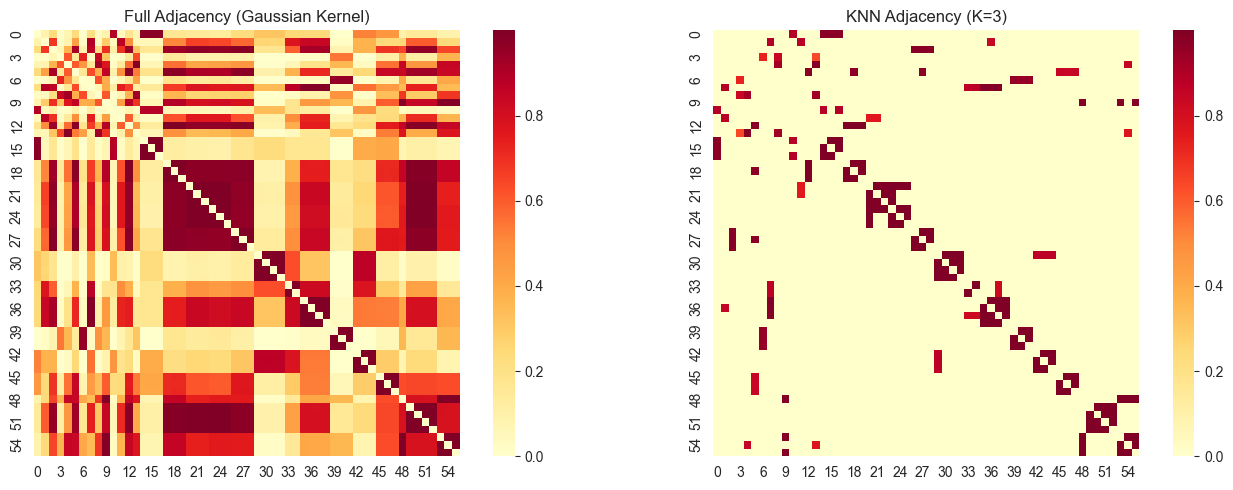

In [18]:
# Get unique stations with coordinates
graph_stations = stations[stations['station_id'].isin(df['station_id'].unique())].copy()
graph_stations = graph_stations.sort_values('station_id').reset_index(drop=True)
n_nodes = len(graph_stations)
print(f"Graph nodes (stations): {n_nodes}")

# Station ID → node index mapping
station_to_idx = {sid: i for i, sid in enumerate(graph_stations['station_id'])}

# ── Distance-based adjacency matrix ──
coords = graph_stations[['latitude', 'longitude']].values
dist_matrix = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        d = haversine(coords[i,0], coords[i,1], coords[j,0], coords[j,1])
        dist_matrix[i,j] = d
        dist_matrix[j,i] = d

# Gaussian kernel: A[i][j] = exp(-dist^2 / sigma^2)
sigma = np.median(dist_matrix[dist_matrix > 0])
adj_full = np.exp(-dist_matrix**2 / sigma**2)
np.fill_diagonal(adj_full, 0)

# K-Nearest Neighbors sparsification (K=3)
adj_knn = np.zeros_like(adj_full)
for i in range(n_nodes):
    # Get K nearest neighbors (excluding self)
    neighbor_idxs = np.argsort(dist_matrix[i])[:K_NEIGHBORS+1]
    neighbor_idxs = neighbor_idxs[neighbor_idxs != i][:K_NEIGHBORS]
    for j in neighbor_idxs:
        adj_knn[i, j] = adj_full[i, j]
        adj_knn[j, i] = adj_full[j, i]  # symmetric

# Save
np.save(OUTPUT_DIR / 'adj_matrix_full.npy', adj_full)
np.save(OUTPUT_DIR / 'adj_matrix_knn.npy', adj_knn)
sparse.save_npz(OUTPUT_DIR / 'adj_matrix_knn_sparse.npz', sparse.csr_matrix(adj_knn))

# Save station-to-index mapping
pd.DataFrame({
    'station_id': graph_stations['station_id'],
    'node_idx': range(n_nodes),
    'latitude': graph_stations['latitude'],
    'longitude': graph_stations['longitude'],
}).to_csv(OUTPUT_DIR / 'station_node_mapping.csv', index=False)

print(f"\nAdjacency matrix shape: {adj_knn.shape}")
print(f"Non-zero entries: {(adj_knn > 0).sum()}")
print(f"Sigma (median distance): {sigma:.1f} km")

# Visualize adjacency matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title('Full Adjacency (Gaussian Kernel)')
sns.heatmap(adj_full, ax=axes[0], cmap='YlOrRd', square=True)
axes[1].set_title(f'KNN Adjacency (K={K_NEIGHBORS})')
sns.heatmap(adj_knn, ax=axes[1], cmap='YlOrRd', square=True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'adjacency_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Exploratory Data Analysis

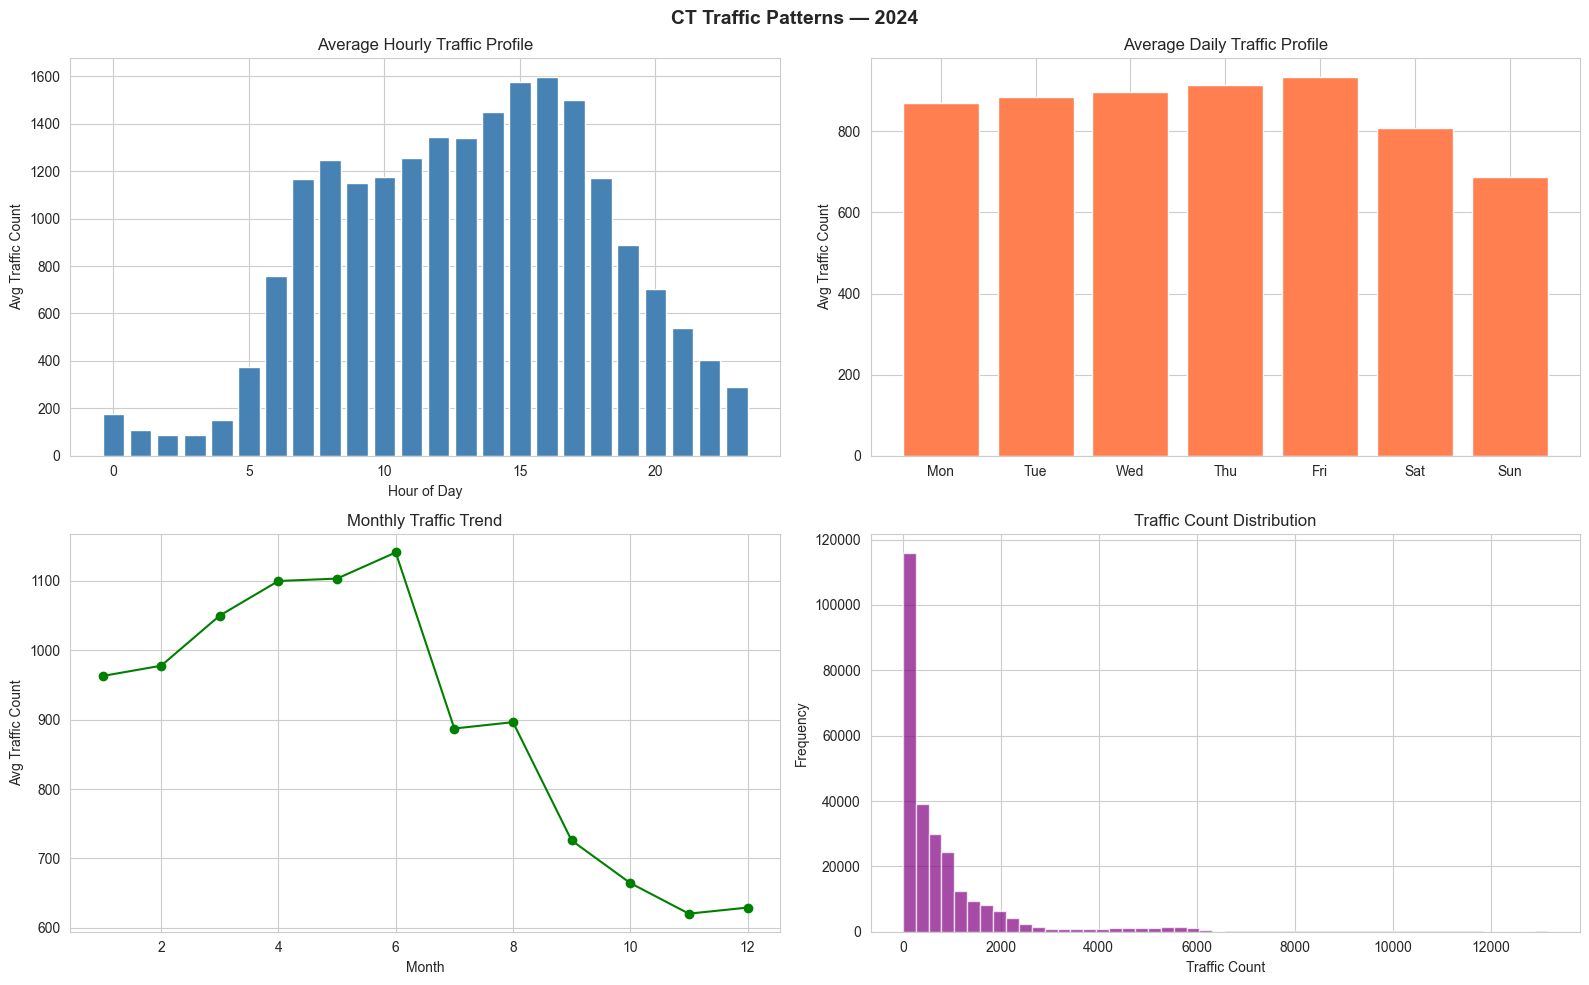

In [19]:
# ── 9a: Overall traffic patterns ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly profile
hourly_avg = df.groupby('hour')['traffic_count'].mean()
axes[0,0].bar(hourly_avg.index, hourly_avg.values, color='steelblue')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Avg Traffic Count')
axes[0,0].set_title('Average Hourly Traffic Profile')

# Day-of-week profile
dow_avg = df.groupby('day_of_week')['traffic_count'].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[0,1].bar(range(7), dow_avg.values, color='coral', tick_label=dow_labels)
axes[0,1].set_ylabel('Avg Traffic Count')
axes[0,1].set_title('Average Daily Traffic Profile')

# Monthly trend
monthly_avg = df.groupby('month')['traffic_count'].mean()
axes[1,0].plot(monthly_avg.index, monthly_avg.values, 'o-', color='green')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Avg Traffic Count')
axes[1,0].set_title('Monthly Traffic Trend')

# Distribution of traffic counts
axes[1,1].hist(df['traffic_count'], bins=50, color='purple', alpha=0.7, edgecolor='white')
axes[1,1].set_xlabel('Traffic Count')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Traffic Count Distribution')

plt.suptitle(f'CT Traffic Patterns — {TARGET_YEAR}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_traffic_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

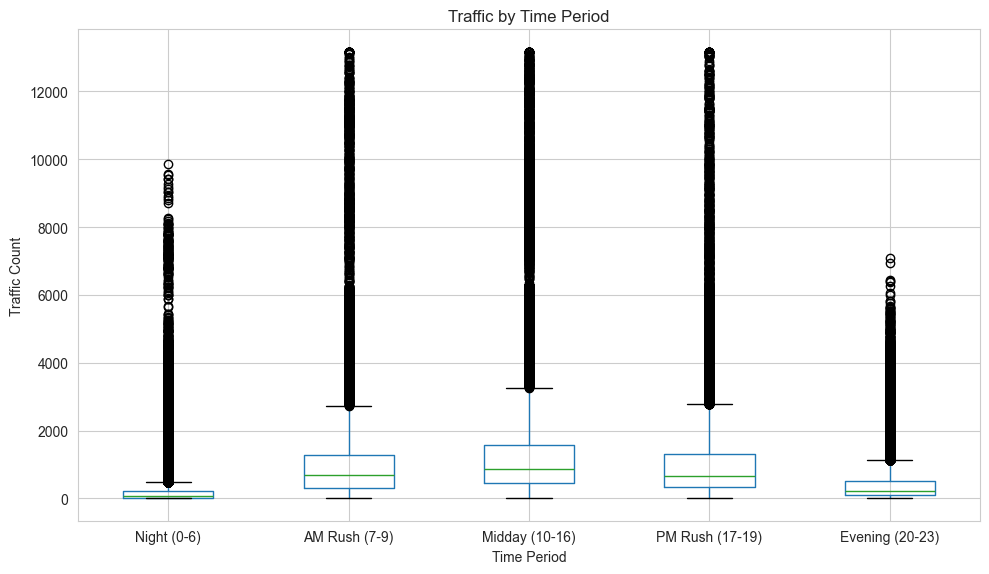

In [20]:
# ── 9b: Rush hour vs off-peak ──
df['period'] = pd.cut(
    df['hour'],
    bins=[-1, 6, 9, 16, 19, 24],
    labels=['Night (0-6)', 'AM Rush (7-9)', 'Midday (10-16)', 'PM Rush (17-19)', 'Evening (20-23)']
)

fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='traffic_count', by='period', ax=ax)
ax.set_xlabel('Time Period')
ax.set_ylabel('Traffic Count')
ax.set_title('Traffic by Time Period')
plt.suptitle('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_rush_hour.png', dpi=150, bbox_inches='tight')
plt.show()

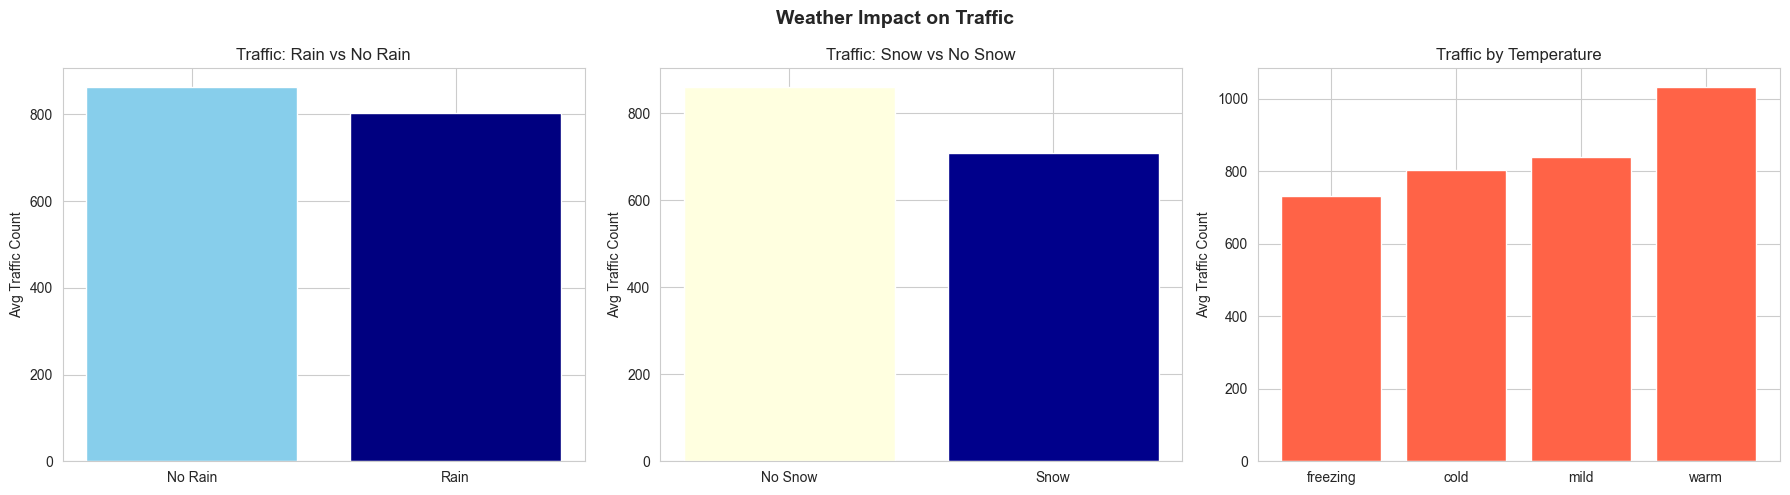

In [21]:
# ── 9c: Weather impact ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rain vs no rain
rain_groups = df.groupby('is_raining')['traffic_count'].mean()
axes[0].bar(['No Rain', 'Rain'], rain_groups.values, color=['skyblue', 'navy'])
axes[0].set_ylabel('Avg Traffic Count')
axes[0].set_title('Traffic: Rain vs No Rain')

# Snow vs no snow
snow_groups = df.groupby('is_snowing')['traffic_count'].mean()
axes[1].bar(['No Snow', 'Snow'], snow_groups.values, color=['lightyellow', 'darkblue'])
axes[1].set_ylabel('Avg Traffic Count')
axes[1].set_title('Traffic: Snow vs No Snow')

# Temperature vs traffic
temp_groups = df.groupby('temp_bin', observed=True)['traffic_count'].mean()
axes[2].bar(temp_groups.index.astype(str), temp_groups.values, color='tomato')
axes[2].set_ylabel('Avg Traffic Count')
axes[2].set_title('Traffic by Temperature')

plt.suptitle('Weather Impact on Traffic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_weather_impact.png', dpi=150, bbox_inches='tight')
plt.show()

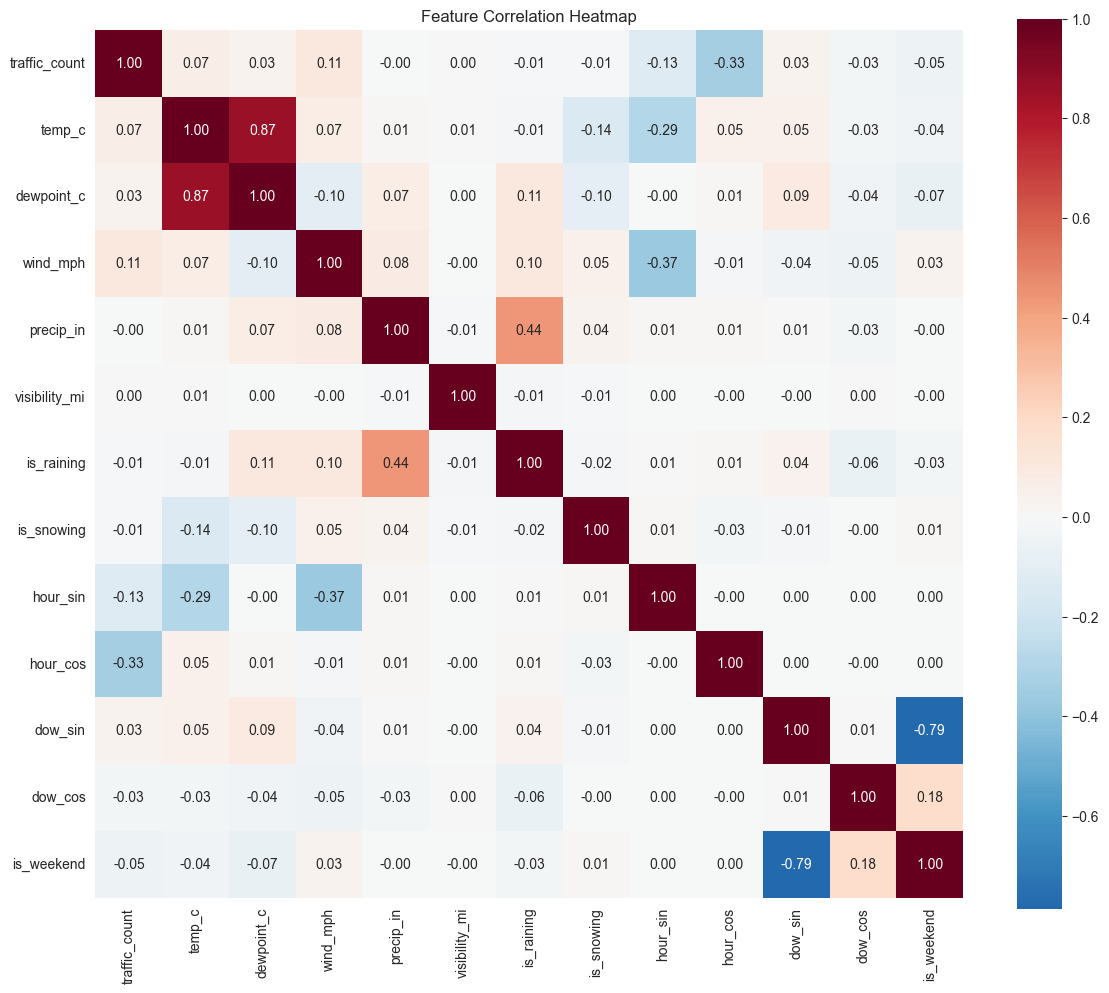

In [22]:
# ── 9d: Correlation heatmap ──
corr_cols = [
    'traffic_count', 'temp_c', 'dewpoint_c', 'wind_mph',
    'precip_in', 'visibility_mi', 'is_raining', 'is_snowing',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend'
]
corr_cols = [c for c in corr_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

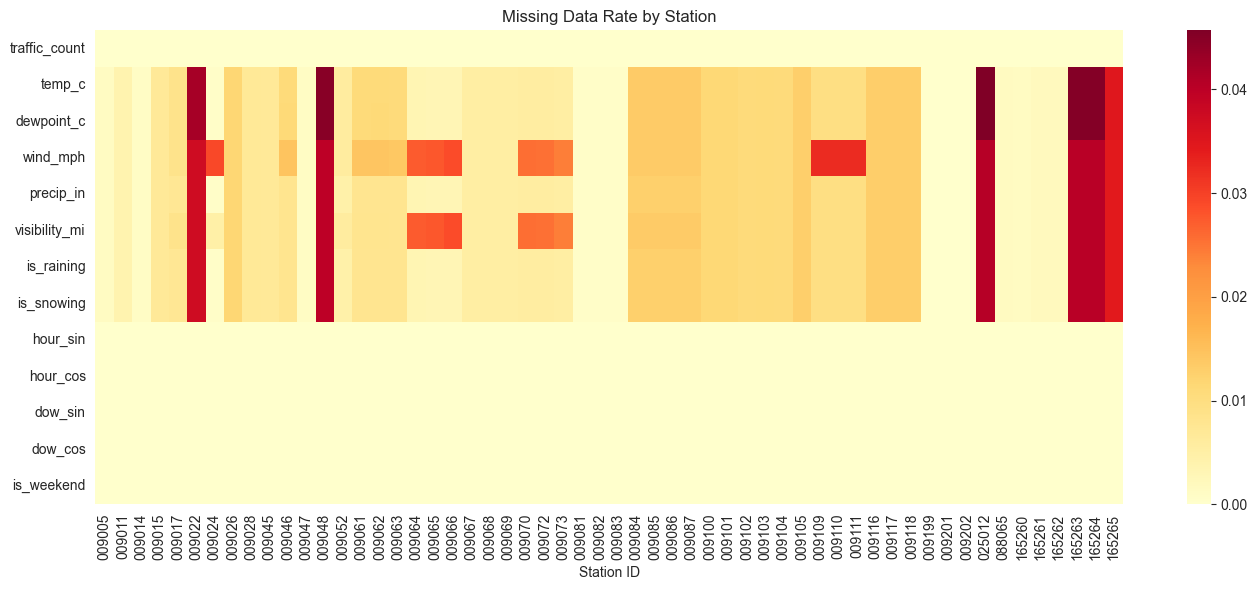

In [23]:
# ── 9e: Missing data heatmap ──
fig, ax = plt.subplots(figsize=(14, 6))
missing_by_station = (
    df.groupby('station_id')[corr_cols]
    .apply(lambda x: x.isnull().mean())
)
sns.heatmap(missing_by_station.T, cmap='YlOrRd', ax=ax)
ax.set_title('Missing Data Rate by Station')
ax.set_xlabel('Station ID')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── 9f: Spatial map of stations ──
try:
    import folium
    from folium.plugins import HeatMap

    ct_center = [41.6, -72.7]
    m = folium.Map(location=ct_center, zoom_start=9)

    # Traffic stations
    for _, row in graph_stations.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=5, color='blue', fill=True, popup=f"Traffic: {row['station_id']}"
        ).add_to(m)

    # Weather stations
    for _, row in asos_stations.iterrows():
        folium.Marker(
            location=[row['weather_lat'], row['weather_lon']],
            icon=folium.Icon(color='red', icon='cloud'),
            popup=f"Weather: {row['weather_station_id']}\n{row['weather_station_name']}"
        ).add_to(m)

    m.save(str(OUTPUT_DIR / 'station_map.html'))
    print("Map saved to processed/station_map.html")
    display(m)
except ImportError:
    print("Install folium for interactive maps: pip install folium")
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(graph_stations['longitude'], graph_stations['latitude'],
               c='blue', s=30, label='Traffic Stations')
    ax.scatter(asos_stations['weather_lon'], asos_stations['weather_lat'],
               c='red', s=100, marker='*', label='Weather Stations')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title('CT Station Locations')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'station_map.png', dpi=150, bbox_inches='tight')
    plt.show()

Map saved to processed/station_map.html


---
## Step 10 — Save Processed Data

In [25]:
# Drop temporary / categorical columns not needed for modeling
drop_cols = ['period', 'temp_bin', 'precip_bin', 'nearest_weather_station']
df_save = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Save main dataset
df_save.to_csv(OUTPUT_DIR / f'ct_traffic_weather_{TARGET_YEAR}.csv', index=False)
print(f"Saved: ct_traffic_weather_{TARGET_YEAR}.csv  ({len(df_save):,} rows, {len(df_save.columns)} cols)")

# Save station metadata
graph_stations.to_csv(OUTPUT_DIR / 'ct_stations.csv', index=False)
print(f"Saved: ct_stations.csv  ({len(graph_stations)} stations)")

# Summary
print(f"\n{'='*60}")
print(f"DATA PIPELINE COMPLETE")
print(f"{'='*60}")
print(f"Stations:       {df_save['station_id'].nunique()}")
print(f"Date range:     {df_save['timestamp'].min()} → {df_save['timestamp'].max()}")
print(f"Total records:  {len(df_save):,}")
print(f"Features:       {len(df_save.columns)}")
print(f"\nOutput files in {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s} {size_mb:.1f} MB")

Saved: ct_traffic_weather_2024.csv  (270,120 rows, 30 cols)
Saved: ct_stations.csv  (56 stations)

DATA PIPELINE COMPLETE
Stations:       56
Date range:     2024-01-02 00:00:00 → 2024-12-31 23:00:00
Total records:  270,120
Features:       30

Output files in C:\Users\owner\Downloads\Masters\Masters_Spring_2026\Advanced Deep Learning\Traffic Project 2\processed:
  adj_matrix_full.npy                      0.0 MB
  adj_matrix_knn.npy                       0.0 MB
  adj_matrix_knn_sparse.npz                0.0 MB
  adjacency_matrix.png                     0.1 MB
  ct_asos_weather_2024.csv                 6.5 MB
  ct_stations.csv                          0.0 MB
  ct_traffic_weather_2024.csv              72.0 MB
  eda_correlation.png                      0.2 MB
  eda_missing_data.png                     0.1 MB
  eda_rush_hour.png                        0.0 MB
  eda_traffic_patterns.png                 0.1 MB
  eda_weather_impact.png                   0.1 MB
  station_map.html                 